# Multi-Observation CNN + NSF Solar Regression

Does training on more solar observations, combined with per-observation normalisation,
improve predictions of AIA intensities and HMI magnetic flux from Surya patch embeddings?

## Design

| | Experiment A | Experiment B |
|---|---|---|
| **Training** | 1 observation (2012-01-14) | 3 observations (2012-01-14, 2013-01-01, 2013-01-04) |
| **Validation** | 2012-01-01 (held out, same for both) | ← same |
| **Test** | 2012-01-05 (held out, same for both) | ← same |

**Model pipeline:** VanillaCNN encoder (1280→512→256→128, 5×5 spatial neighbourhood) →
freeze encoder → CNN-conditioned NSF (4-D joint posterior over reordered targets).

**Target order (easiest→hardest):** AIA 193, AIA 304, |Mag flux|, Mag flux

**Per-observation normalisation:** both embeddings (channel-wise) and targets are
centred by subtracting their per-observation mean before training, to remove
inter-observation level shifts (e.g. solar-cycle variation in AIA 193 flux).

**Grid coordinates:** inferred from a 256×256 regular grid (step ≈ 9.6 arcsec/patch),
selecting the N patches closest to disc centre in row-major order.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, ConcatDataset
import zuko
import copy
from pathlib import Path

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [2]:
SCALAR_DIR   = Path('/Users/juramaga/science/helio/email/scalar')
GRID_SIZE    = 256
STEP_ARCSEC  = 9.6
K            = 5
N_SAMPLES    = 2000
PERM         = [0, 1, 3, 2]
PERM_INV     = [0, 1, 3, 2]
TARGET_NAMES = ['AIA 193', 'AIA 304', 'Mag flux', '|Mag flux|']

OBS_TEST = 'solar_scalar_2012-01-05.npz'
OBS_VAL  = 'solar_scalar_2012-01-01.npz'

# Experiment A: single observation
OBS_TRAIN_A = ['solar_scalar_2012-01-14.npz']

# Experiment B: 3 observations — testing per-obs normalisation before scaling to 20
OBS_TRAIN_B = [
    'solar_scalar_2012-01-14.npz',
    'solar_scalar_2013-01-01.npz',
    'solar_scalar_2013-01-04.npz',
]

# All 20 available training obs (excludes val and test) — used for spatial visualisation
ALL_TRAIN_OBS = [
    'solar_scalar_2012-01-14.npz', 'solar_scalar_2012-02-13.npz',
    'solar_scalar_2013-01-01.npz', 'solar_scalar_2013-01-04.npz',
    'solar_scalar_2013-01-07.npz', 'solar_scalar_2013-01-10.npz',
    'solar_scalar_2013-01-14.npz', 'solar_scalar_2013-02-01.npz',
    'solar_scalar_2013-02-05.npz', 'solar_scalar_2013-02-13.npz',
    'solar_scalar_2014-01-01.npz', 'solar_scalar_2014-01-10.npz',
    'solar_scalar_2014-01-15.npz', 'solar_scalar_2014-02-05.npz',
    'solar_scalar_2014-02-10.npz', 'solar_scalar_2014-02-12.npz',
    'solar_scalar_2015-02-05.npz', 'solar_scalar_2015-02-07.npz',
    'solar_scalar_2015-02-08.npz', 'solar_scalar_2015-02-13.npz',
]

In [3]:
def infer_disk_center(N_total, grid_size=GRID_SIZE):
    """Estimate the solar disk centre (cx, cy) in grid pixels for one observation.

    Fits a parabola to the squared chord-width distribution (n(r)^2 vs r and
    n(c)^2 vs c) and applies a bias correction derived from the known WCS centre
    of the test observation (2012-01-05):
      parabola-fit bias: DCX = -0.0769 px, DCY = -0.0098 px.

    This corrects for the systematic offset introduced by the non-integer
    fractional part of the true disk centre in the chord-width quantisation.
    """
    CX0 = (grid_size - 1) / 2.0 - 3.512 / 9.6121   # WCS-derived initial guess
    CY0 = (grid_size - 1) / 2.0 + 5.602 / 9.6121
    DCX, DCY = -0.0769, -0.0098                     # parabola-fit bias correction

    cx, cy = CX0, CY0
    for _ in range(2):
        rr, cc = np.mgrid[0:grid_size, 0:grid_size]
        dist = np.sqrt((rr - cy)**2 + (cc - cx)**2).ravel()
        keep = np.sort(np.argsort(dist)[:N_total])
        rows = rr.ravel()[keep].astype(int)
        cols = cc.ravel()[keep].astype(int)

        row_counts = np.bincount(rows, minlength=grid_size).astype(float)
        col_counts = np.bincount(cols, minlength=grid_size).astype(float)

        r_arr = np.arange(grid_size, dtype=float)
        mask_r = row_counts > 5
        X_r = np.column_stack([np.ones(mask_r.sum()), r_arr[mask_r], r_arr[mask_r]**2])
        _, Br, Cr = np.linalg.lstsq(X_r, row_counts[mask_r]**2, rcond=None)[0]
        cy = -Br / (2 * Cr)

        c_arr = np.arange(grid_size, dtype=float)
        mask_c = col_counts > 5
        X_c = np.column_stack([np.ones(mask_c.sum()), c_arr[mask_c], c_arr[mask_c]**2])
        _, Bc, Cc = np.linalg.lstsq(X_c, col_counts[mask_c]**2, rcond=None)[0]
        cx = -Bc / (2 * Cc)

    return cx + DCX, cy + DCY


def make_grid_coords(N_total, grid_size=GRID_SIZE, step=STEP_ARCSEC, cx=None, cy=None):
    """Map N_total on-disc patches to (row, col, patch_x, patch_y).

    Selects the N_total grid cells closest to disc centre, returned in
    row-major (C) order — matching storage order in scalar files.
    N_total must be the TOTAL patch count (including NaN edge patches)
    so the circular radius estimate is correct.

    cx / cy: disc centre in grid pixels. Defaults to WCS-derived values for
    the test observation; pass per-observation values from infer_disk_center()
    for improved accuracy with other observations.
    """
    if cx is None:
        cx = (grid_size - 1) / 2.0 - 3.512 / 9.6121   # ≈ 127.135
    if cy is None:
        cy = (grid_size - 1) / 2.0 + 5.602 / 9.6121   # ≈ 128.083
    rr, cc = np.mgrid[0:grid_size, 0:grid_size]
    dist = np.sqrt((rr - cy)**2 + (cc - cx)**2).ravel()
    keep = np.sort(np.argsort(dist)[:N_total])   # sorted flat-idx → row-major order
    r = rr.ravel()[keep].astype(int)
    c = cc.ravel()[keep].astype(int)
    return r, c, (c - cx) * step, (r - cy) * step


def load_obs(fname):
    """Load a scalar .npz file; return dict with derived grid positions.

    Grid positions are computed using the total patch count (including NaN
    edge patches) so the circular radius estimate is accurate. NaN patches
    are then filtered and excluded from the returned arrays.
    """
    d      = np.load(SCALAR_DIR / fname, allow_pickle=True)
    emb    = d['embeddings'].astype(np.float32)
    aia193 = d['aia193'].astype(np.float64)
    aia304 = d['aia304'].astype(np.float64)
    mag    = d['magnetic_flux'].astype(np.float64)
    frac   = d['filament_fraction'].astype(np.float64)
    N_total = len(aia193)                           # total on-disc patches (incl. NaN)
    row, col, px, py = make_grid_coords(N_total)
    valid  = np.isfinite(aia193) & np.isfinite(aia304) & np.isfinite(mag) & np.isfinite(frac)
    return dict(
        embeddings        = emb[valid],
        aia193            = aia193[valid],
        aia304            = aia304[valid],
        magnetic_flux     = mag[valid],
        filament_fraction = frac[valid],
        row=row[valid], col=col[valid], patch_x=px[valid], patch_y=py[valid],
        N=int(valid.sum()),
    )


def build_targets(obs):
    """Return (N,4) raw log1p-transformed targets: [AIA193, AIA304, mag, |mag|]."""
    a193 = np.log1p(np.clip(obs['aia193'], 0, None))
    a304 = np.log1p(np.clip(obs['aia304'], 0, None))
    mag  = obs['magnetic_flux']
    return np.column_stack([a193, a304, mag, np.abs(mag)]).astype(np.float32)


def build_emb_padded(obs, K=K):
    """Place embeddings on a 2-D grid and reflect-pad by K//2 on each side.
    Embeddings are per-observation centred (subtract channel-wise mean) to
    remove global level shifts between dates before spatial convolution.
    """
    PAD = K // 2
    C   = obs['embeddings'].shape[1]
    emb = obs['embeddings'] - obs['embeddings'].mean(axis=0, keepdims=True)
    grid = np.zeros((GRID_SIZE, GRID_SIZE, C), dtype=np.float32)
    grid[obs['row'], obs['col']] = emb
    return np.pad(grid, ((PAD, PAD), (PAD, PAD), (0, 0)), mode='reflect')

In [4]:
class SpatialPatchDataset(Dataset):
    """Returns a (C, K, K) neighbourhood embedding centred on each patch."""
    def __init__(self, emb_padded, rows, cols, Y_s, K=K):
        self.emb  = emb_padded
        self.rows = rows
        self.cols = cols
        self.Y    = torch.tensor(Y_s, dtype=torch.float32)
        self.K    = K
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r, c  = self.rows[i], self.cols[i]
        patch = self.emb[r:r+self.K, c:c+self.K, :]      # (K, K, C)
        return torch.tensor(patch).permute(2, 0, 1), self.Y[i]  # (C,K,K), (4,)


class VanillaCNN(nn.Module):
    def __init__(self, in_ch=1280, out=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 512, 3, padding=1), nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512,  256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256,  128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, out),
        )
    def forward(self, x): return self.net(x)

In [5]:
def train_cnn(model, tr_dl, val_dl, max_epochs=150, patience=15, lr=3e-4, name='CNN'):
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=7, factor=0.5)
    crit = nn.MSELoss()
    best_val, best_state, wait = np.inf, None, 0
    tr_hist, val_hist = [], []
    for ep in range(1, max_epochs + 1):
        model.train()
        tot = 0.
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            l = crit(model(xb), yb)
            opt.zero_grad(); l.backward(); opt.step()
            tot += l.item() * len(yb)
        tr_hist.append(tot / len(tr_dl.dataset))
        model.eval()
        vtot = 0.
        with torch.no_grad():
            for xb, yb in val_dl:
                vtot += crit(model(xb.to(device)), yb.to(device)).item() * len(yb)
        vl = vtot / len(val_dl.dataset)
        val_hist.append(vl); sch.step(vl)
        if vl < best_val:
            best_val, best_state, wait = vl, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f'{name}: early stop ep {ep}'); break
        if ep % 30 == 0:
            print(f'{name} ep {ep:3d}  train={tr_hist[-1]:.4f}  val={vl:.4f}')
    model.load_state_dict(best_state)
    return tr_hist, val_hist


def get_contexts(cnn, dataset, bs=256):
    """Extract frozen encoder contexts for every patch in dataset."""
    encoder = nn.Sequential(*list(cnn.net.children())[:-1]).to(device).eval()
    for p in encoder.parameters(): p.requires_grad_(False)
    dl  = DataLoader(dataset, batch_size=bs, shuffle=False)
    out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(encoder(xb.to(device)).cpu())
    return torch.cat(out, dim=0)   # (N, 128)


def train_nsf(ctx_tr, y_tr_s, ctx_val, y_val_s,
              max_ep=200, patience=20, lr=3e-4, bs=256, name='NSF'):
    """Train NSF on PERM-reordered targets (standardised per-obs-centred space)."""
    y_tr_p  = y_tr_s[:, PERM];   y_val_p = y_val_s[:, PERM]
    tr_dl   = DataLoader(TensorDataset(ctx_tr,  y_tr_p),  batch_size=bs, shuffle=True)
    val_dl  = DataLoader(TensorDataset(ctx_val, y_val_p), batch_size=bs*4)
    flow    = zuko.flows.NSF(features=4, context=128, transforms=6, bins=8,
                              hidden_features=[64, 64]).to(device)
    opt = torch.optim.AdamW(flow.parameters(), lr=lr, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5)
    best_val, best_state, wait = np.inf, None, 0
    tr_nll, val_nll = [], []
    for ep in range(1, max_ep + 1):
        flow.train()
        tot = 0.
        for cb, yb in tr_dl:
            cb, yb = cb.to(device), yb.to(device)
            l = -flow(cb).log_prob(yb).mean()
            opt.zero_grad(); l.backward(); opt.step()
            tot += l.item() * len(yb)
        tr_nll.append(tot / len(ctx_tr))
        flow.eval()
        vtot = 0.
        with torch.no_grad():
            for cb, yb in val_dl:
                vtot += -flow(cb.to(device)).log_prob(yb.to(device)).mean().item() * len(yb)
        vl = vtot / len(ctx_val); val_nll.append(vl); sch.step(vl)
        if vl < best_val:
            best_val, best_state, wait = vl, copy.deepcopy(flow.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f'{name}: early stop ep {ep}'); break
        if ep % 40 == 0:
            print(f'{name} ep {ep:3d}  NLL train={tr_nll[-1]:.4f}  val={vl:.4f}')
    flow.load_state_dict(best_state)
    print(f'{name}: best val NLL = {best_val:.4f}')
    return flow, tr_nll, val_nll


def evaluate_flow(flow, ctx_te, y_te_s, scaler_y, mu_te_raw=None, n_samples=N_SAMPLES):
    """Sample posteriors; return (samp_s, y_pred_phys, y_true_phys).

    samp_s  — (N_te, N_samp, 4) in standardised per-obs-centred space (for coverage).
    y_pred/y_true — in physical (log1p) space, with per-obs mean added back if
                    mu_te_raw is provided.
    """
    flow.eval()
    samps = []
    dl = DataLoader(TensorDataset(ctx_te), batch_size=256)
    with torch.no_grad():
        for (cb,) in dl:
            s = flow(cb.to(device)).sample((n_samples,))
            samps.append(s.permute(1, 0, 2).cpu())
    samp_perm = torch.cat(samps, dim=0).numpy()
    samp_orig = samp_perm[:, :, PERM_INV]                         # (N_te, N_samp, 4)
    y_pred_c  = scaler_y.inverse_transform(samp_orig.mean(1))     # centred space
    y_te_np   = y_te_s.numpy() if hasattr(y_te_s, 'numpy') else y_te_s
    y_true_c  = scaler_y.inverse_transform(y_te_np)
    if mu_te_raw is not None:
        return samp_orig, y_pred_c + mu_te_raw, y_true_c + mu_te_raw
    return samp_orig, y_pred_c, y_true_c


def to_physical_samp(samp_orig_s, scaler_y, mu_te_raw=None):
    """Inverse-transform each posterior sample to physical space."""
    N_te, N_samp, D = samp_orig_s.shape
    flat      = samp_orig_s.reshape(-1, D)
    flat_phys = scaler_y.inverse_transform(flat)
    if mu_te_raw is not None:
        flat_phys = flat_phys + mu_te_raw
    return flat_phys.reshape(N_te, N_samp, D)


def emp_coverage(samp, y_true_s, levels):
    """samp: (N_te, N_samp, D) standardised; y_true_s: (N_te, D)."""
    cov = np.zeros((len(levels), samp.shape[-1]))
    for li, alpha in enumerate(levels):
        lo = np.quantile(samp, (1-alpha)/2, axis=1)
        hi = np.quantile(samp, (1+alpha)/2, axis=1)
        cov[li] = ((y_true_s >= lo) & (y_true_s <= hi)).mean(axis=0)
    return cov

## Spatial AIA 193 Å Maps — All 22 Observations

AIA 193 Å intensity on the patch grid for all 22 observations
(20 training + validation + test).

Grid projection:
- **Test obs (2012-01-05):** exact WCS positions from `patch_data_all_modalities.npz`
  (step = 9.6121 arcsec, centre fitted from the reference file).
- **All other obs:** `make_grid_coords(N_total)` — circular approximation using the
  total on-disc patch count (including NaN edge patches) for an accurate radius.

Red border = test  |  Orange border = validation  |  No border = training.

Building AIA 193 maps (22 observations)...


/var/folders/57/n7hhtjss0tg3fjpkz6p_ds7r0000gn/T/ipykernel_56393/335605717.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


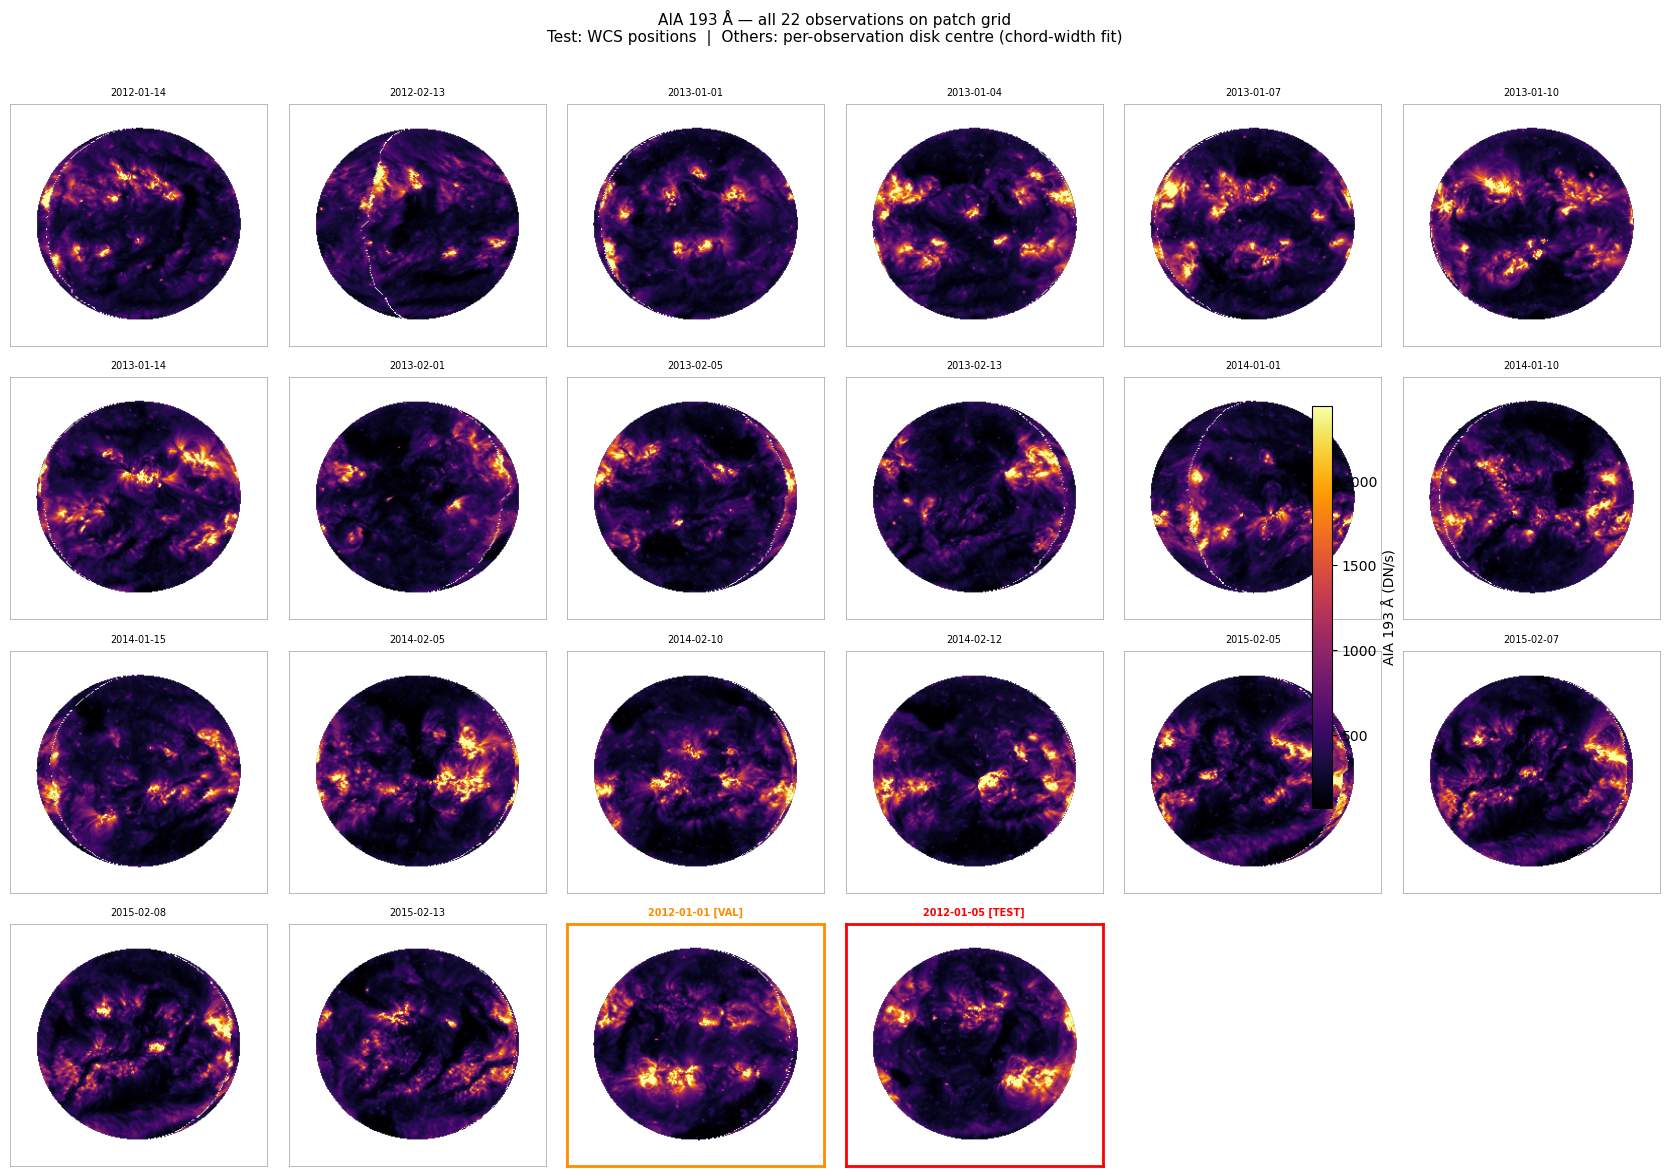

Colour scale: 68–2441 DN/s  |  22 panels


In [4]:
# WCS parameters for test-obs exact mapping (measured from patch_data_all_modalities.npz)
_STEP_WCS = 9.6121
_CX_ARC   =  3.512
_CY_ARC   = -5.602
_REF_FILE = Path('/Users/juramaga/science/helio/email/patch_data_all_modalities.npz')


def obs_to_aia193_map(fname):
    """Return (256, 256) AIA 193 grid.

    Test observation: exact WCS positions from the reference npz.
    All others: per-observation disk centre from infer_disk_center().
    """
    if fname == OBS_TEST:
        d      = np.load(_REF_FILE, allow_pickle=True)
        px     = d['patch_x'].astype(np.float64)
        py     = d['patch_y'].astype(np.float64)
        a193   = d['aia193_intensity'].astype(np.float64)
        valid  = np.isfinite(a193)
        cg = np.clip(np.round((px - _CX_ARC) / _STEP_WCS + 127.5).astype(int), 0, GRID_SIZE-1)
        rg = np.clip(np.round((py - _CY_ARC) / _STEP_WCS + 127.5).astype(int), 0, GRID_SIZE-1)
        grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)
        grid[rg[valid], cg[valid]] = a193[valid]
        return grid
    d       = np.load(SCALAR_DIR / fname, allow_pickle=True)
    aia193  = d['aia193'].astype(np.float64)
    N_total = len(aia193)
    cx, cy  = infer_disk_center(N_total)
    row, col, _, _ = make_grid_coords(N_total, cx=cx, cy=cy)
    valid   = np.isfinite(aia193)
    grid    = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    grid[row[valid], col[valid]] = aia193[valid]
    return grid


print('Building AIA 193 maps (22 observations)...')
all_panels = []
for f in ALL_TRAIN_OBS:
    label = f.replace('solar_scalar_', '').replace('.npz', '')
    all_panels.append(('train', label, obs_to_aia193_map(f)))

all_panels.append(('val',
                   OBS_VAL.replace('solar_scalar_', '').replace('.npz', ''),
                   obs_to_aia193_map(OBS_VAL)))
all_panels.append(('test',
                   OBS_TEST.replace('solar_scalar_', '').replace('.npz', ''),
                   obs_to_aia193_map(OBS_TEST)))

# Shared colour scale (1st–99th percentile across all panels)
all_finite = np.concatenate([g[np.isfinite(g)].ravel() for _, _, g in all_panels])
vmin, vmax = np.percentile(all_finite, 1), np.percentile(all_finite, 99)

BORDER = {'test': ('red', 2.0), 'val': ('darkorange', 2.0), 'train': ('#888888', 0.4)}
TITLE_COL = {'test': 'red', 'val': 'darkorange', 'train': 'k'}

ncols, nrows = 6, 4      # 24 slots for 22 panels
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.9))
axs = axes.ravel()

for idx, (role, label, grid) in enumerate(all_panels):
    ax = axs[idx]
    ec, lw = BORDER[role]
    ax.imshow(grid, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax, aspect='auto')
    suffix = f' [{role.upper()}]' if role != 'train' else ''
    ax.set_title(label + suffix, fontsize=7,
                 color=TITLE_COL[role],
                 fontweight='bold' if role != 'train' else 'normal')
    for sp in ax.spines.values():
        sp.set_edgecolor(ec); sp.set_linewidth(lw)
    ax.set_xticks([]); ax.set_yticks([])

for idx in range(len(all_panels), nrows * ncols):
    axs[idx].set_visible(False)

im_ref = axs[0].get_images()[0]
fig.colorbar(im_ref, ax=axs.tolist(), shrink=0.45, pad=0.02, label='AIA 193 Å (DN/s)')
plt.suptitle(
    'AIA 193 Å — all 22 observations on patch grid\n'
    'Test: WCS positions  |  Others: per-observation disk centre (chord-width fit)',
    y=1.01, fontsize=11
)
plt.tight_layout()
plt.show()
print(f'Colour scale: {vmin:.0f}–{vmax:.0f} DN/s  |  {len(all_panels)} panels')

### Test observation: WCS-derived grid vs actual WCS scatter

Diagnostic comparison for 2012-01-05. Both panels use the actual WCS coordinates
from `patch_data_all_modalities.npz`.

**Left:** each patch placed at its true integer pixel position, derived by inverting
the WCS transformation: `col = round((patch_x − cx_arc) / step)`,
`row = round((patch_y − cy_arc) / step)` with step = 9.6121 arcsec and
cx_arc / cy_arc fitted from the reference file. The imshow extent covers the full
256 × 256 grid so each pixel subtends exactly one patch-width (≈ 9.61 arcsec).

**Right:** raw WCS scatter — same data, no gridding.

The two panels should look nearly identical if the WCS → grid mapping is correct.

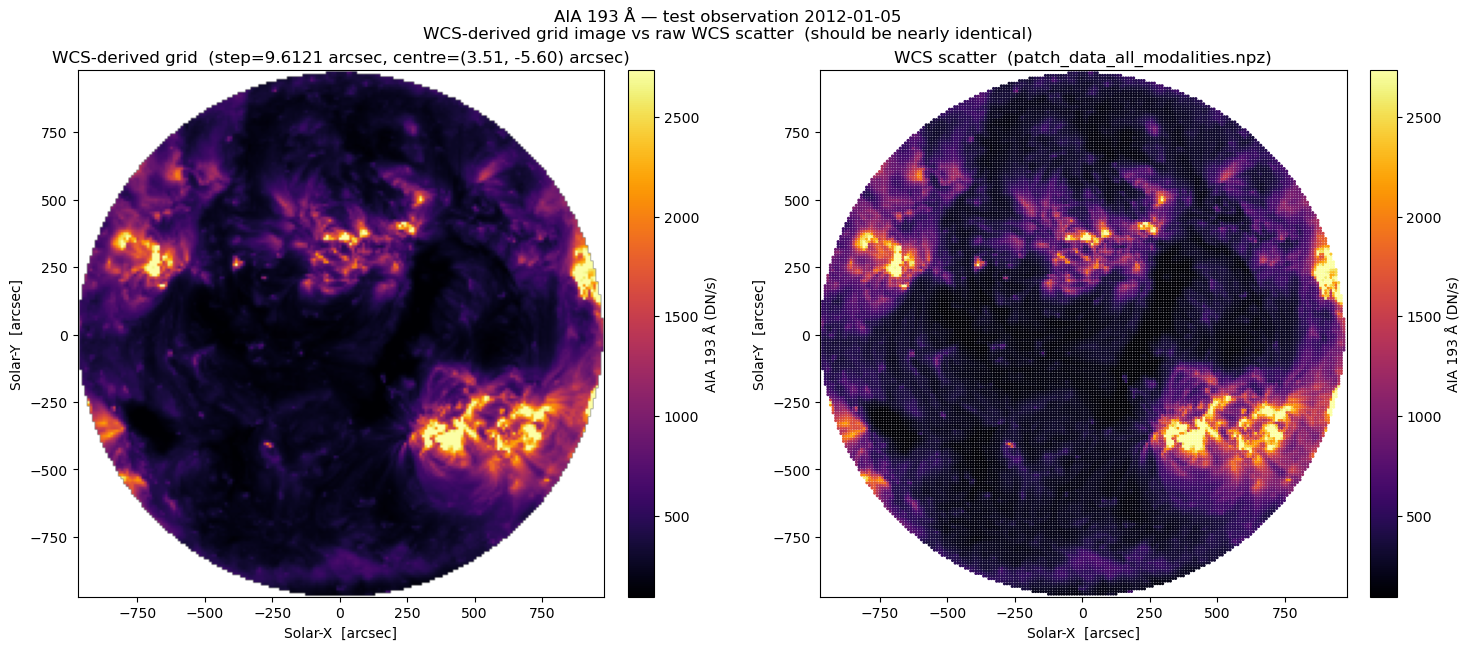

Grid col: 27–228, row: 28–229
WCS Solar-X: -962.6..969.6  Solar-Y: -962.1..970.1
Extent: x=[-1226.8, 1233.9]  y=[-1236.0, 1224.7]


In [4]:
REF_FILE = Path('/Users/juramaga/science/helio/email/patch_data_all_modalities.npz')

# ── WCS parameters measured from reference file ─────────────────────────────
# step_x / step_y from consecutive same-row patch differences: 9.6121 arcsec
# cx_arc: x-arcsec at grid centre col=127.5  → disk centre x ≈ 3.512 arcsec
# cy_arc: y-arcsec at grid centre row=127.5  → fitted so southernmost row = 27
#   cy_arc = py_min + (127.5 − 27) × step = −971.61 + 100.5 × 9.6121 ≈ −5.60
#   disk centre y = cy_arc + 0.5 × step = −5.60 + 4.81 = −0.79 ≈ −0.75 arcsec ✓
STEP_WCS = 9.6121
CX_ARC   =  3.512
CY_ARC   = -5.602

# ── Load reference file ──────────────────────────────────────────────────────
d_ref   = np.load(REF_FILE, allow_pickle=True)
px_all  = d_ref['patch_x'].astype(np.float64)
py_all  = d_ref['patch_y'].astype(np.float64)
a193_r  = d_ref['aia193_intensity'].astype(np.float64)
valid_r = np.isfinite(a193_r)

# ── Convert WCS → integer pixel positions ───────────────────────────────────
col_grid = np.round((px_all - CX_ARC) / STEP_WCS + 127.5).astype(int)
row_grid = np.round((py_all - CY_ARC) / STEP_WCS + 127.5).astype(int)
col_grid = np.clip(col_grid, 0, GRID_SIZE - 1)
row_grid = np.clip(row_grid, 0, GRID_SIZE - 1)

# ── Build grid image ─────────────────────────────────────────────────────────
grid_img = np.full((GRID_SIZE, GRID_SIZE), np.nan)
grid_img[row_grid[valid_r], col_grid[valid_r]] = a193_r[valid_r]

# ── Shared colour scale ──────────────────────────────────────────────────────
vals = a193_r[valid_r]
vmin_c, vmax_c = np.percentile(vals, 1), np.percentile(vals, 99)

# ── Extent: full 256×256 grid in arcsec (pixel-edge convention) ─────────────
# Each pixel maps to exactly STEP_WCS arcsec; extent covers 256 × STEP_WCS arcsec.
x_lo = CX_ARC - 128 * STEP_WCS;  x_hi = CX_ARC + 128 * STEP_WCS
y_lo = CY_ARC - 128 * STEP_WCS;  y_hi = CY_ARC + 128 * STEP_WCS
extent_img = [x_lo, x_hi, y_lo, y_hi]

# ── Axis limits (crop to disk) ───────────────────────────────────────────────
px_v = px_all[valid_r];  py_v = py_all[valid_r]
x_lim = (px_v.min() - STEP_WCS, px_v.max() + STEP_WCS)
y_lim = (py_v.min() - STEP_WCS, py_v.max() + STEP_WCS)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Left — WCS-derived grid image
im0 = axes[0].imshow(
    grid_img, origin='lower', cmap='inferno',
    vmin=vmin_c, vmax=vmax_c, extent=extent_img, aspect='equal'
)
axes[0].set_xlim(x_lim); axes[0].set_ylim(y_lim)
axes[0].set(title=f'WCS-derived grid  (step={STEP_WCS} arcsec, '
                  f'centre=({CX_ARC:.2f}, {CY_ARC:.2f}) arcsec)',
            xlabel='Solar-X  [arcsec]', ylabel='Solar-Y  [arcsec]')
plt.colorbar(im0, ax=axes[0], label='AIA 193 Å (DN/s)', fraction=0.046, pad=0.04)

# Right — raw WCS scatter (ground truth)
sc = axes[1].scatter(
    px_v, py_v, c=a193_r[valid_r], cmap='inferno',
    vmin=vmin_c, vmax=vmax_c, s=5, linewidths=0, rasterized=True
)
axes[1].set_xlim(x_lim); axes[1].set_ylim(y_lim)
axes[1].set(title='WCS scatter  (patch_data_all_modalities.npz)',
            xlabel='Solar-X  [arcsec]', ylabel='Solar-Y  [arcsec]',
            aspect='equal')
plt.colorbar(sc, ax=axes[1], label='AIA 193 Å (DN/s)', fraction=0.046, pad=0.04)

plt.suptitle('AIA 193 Å — test observation 2012-01-05\n'
             'WCS-derived grid image vs raw WCS scatter  (should be nearly identical)',
             fontsize=12)
plt.tight_layout()
plt.show()

print(f'Grid col: {col_grid[valid_r].min()}–{col_grid[valid_r].max()}, '
      f'row: {row_grid[valid_r].min()}–{row_grid[valid_r].max()}')
print(f'WCS Solar-X: {px_v.min():.1f}..{px_v.max():.1f}  '
      f'Solar-Y: {py_v.min():.1f}..{py_v.max():.1f}')
print(f'Extent: x=[{x_lo:.1f}, {x_hi:.1f}]  y=[{y_lo:.1f}, {y_hi:.1f}]')

In [6]:
print('Loading observations...')
obs_test   = load_obs(OBS_TEST)
obs_val    = load_obs(OBS_VAL)
obs_A1     = load_obs(OBS_TRAIN_A[0])
obs_B_list = [load_obs(f) for f in OBS_TRAIN_B]

print(f'  Test  {OBS_TEST}: {obs_test["N"]:,} patches')
print(f'  Val   {OBS_VAL}: {obs_val["N"]:,} patches')
print(f'  Train-A (1 obs):  {obs_A1["N"]:,} patches')
n_B = sum(o['N'] for o in obs_B_list)
print(f'  Train-B ({len(obs_B_list)} obs): {n_B:,} patches total')

Loading observations...


  Test  solar_scalar_2012-01-05.npz: 32,014 patches
  Val   solar_scalar_2012-01-01.npz: 32,012 patches
  Train-A (1 obs):  31,969 patches
  Train-B (3 obs): 95,980 patches total


In [7]:
Y_A1_raw  = build_targets(obs_A1)
Y_B_raw   = [build_targets(o) for o in obs_B_list]
Y_val_raw = build_targets(obs_val)
Y_te_raw  = build_targets(obs_test)

# Per-observation centering: subtract each observation's own channel mean.
# This removes inter-date flux level shifts (e.g. solar-cycle variation in AIA 193)
# so the model learns spatial structure rather than absolute levels.
mu_A1   = Y_A1_raw.mean(axis=0)
mu_B    = [Y.mean(axis=0) for Y in Y_B_raw]
mu_val  = Y_val_raw.mean(axis=0)
mu_test = Y_te_raw.mean(axis=0)     # stored for physical-space denormalisation at test time

Y_A1_c  = Y_A1_raw - mu_A1
Y_B_c   = [Y - mu for Y, mu in zip(Y_B_raw, mu_B)]
Y_val_c = Y_val_raw - mu_val
Y_te_c  = Y_te_raw  - mu_test

# Global StandardScaler on per-obs-centred data (equalises scale across target types)
scaler_y = StandardScaler()
scaler_y.fit(np.concatenate([Y_A1_c] + Y_B_c))

Y_A1_s     = torch.tensor(scaler_y.transform(Y_A1_c),  dtype=torch.float32)
Y_B_s_list = [torch.tensor(scaler_y.transform(Y),      dtype=torch.float32) for Y in Y_B_c]
Y_val_s    = torch.tensor(scaler_y.transform(Y_val_c),  dtype=torch.float32)
Y_test_s   = torch.tensor(scaler_y.transform(Y_te_c),   dtype=torch.float32)

def make_ds(obs, Y_s):
    return SpatialPatchDataset(build_emb_padded(obs), obs['row'], obs['col'], Y_s)

ds_A1     = make_ds(obs_A1, Y_A1_s)
ds_B_list = [make_ds(obs_B_list[i], Y_B_s_list[i]) for i in range(len(obs_B_list))]
ds_val    = make_ds(obs_val,  Y_val_s)
ds_test   = make_ds(obs_test, Y_test_s)

concat_B = ConcatDataset(ds_B_list)
n_trB    = len(concat_B)

dl_trA  = DataLoader(ds_A1,    batch_size=256, shuffle=True)
dl_trB  = DataLoader(concat_B, batch_size=256, shuffle=True)
dl_val  = DataLoader(ds_val,   batch_size=512)
dl_test = DataLoader(ds_test,  batch_size=512)

print(f'Train-A: {len(ds_A1):,} patches (1 obs, per-obs normalised)')
print(f'Train-B: {n_trB:,} patches ({len(obs_B_list)} obs, per-obs normalised)')
print(f'Val:     {len(ds_val):,} patches')
print(f'Test:    {len(ds_test):,} patches')
print(f'mu_test (log1p space): {np.round(mu_test, 4)}')

/var/folders/57/n7hhtjss0tg3fjpkz6p_ds7r0000gn/T/ipykernel_55333/3721155495.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.Y    = torch.tensor(Y_s, dtype=torch.float32)


Train-A: 31,969 patches (1 obs, per-obs normalised)
Train-B: 95,980 patches (3 obs, per-obs normalised)
Val:     32,012 patches
Test:    32,014 patches
mu_test (log1p space): [   5.9684    3.8901 -115.956  2023.2299]


## Experiment A — Single Observation

Training on one observation (2012-01-14, ~32K patches).

CNN-A: early stop ep 16


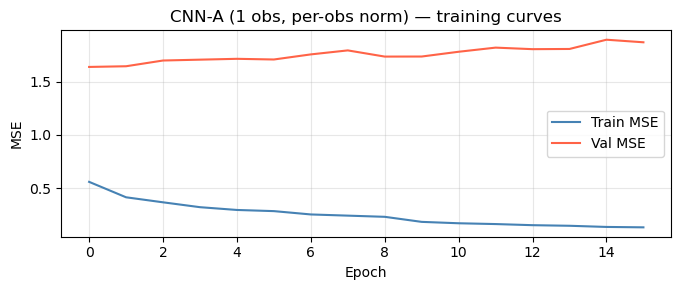

In [8]:
cnn_A = VanillaCNN().to(device)
tr_A, val_A = train_cnn(cnn_A, dl_trA, dl_val, name='CNN-A')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tr_A,  label='Train MSE', color='steelblue')
ax.plot(val_A, label='Val MSE',   color='tomato')
ax.set(xlabel='Epoch', ylabel='MSE', title='CNN-A (1 obs, per-obs norm) — training curves')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Precomputing contexts (CNN-A)...


Context shape: (31969, 128)


NSF-A: early stop ep 21
NSF-A: best val NLL = 5.4611


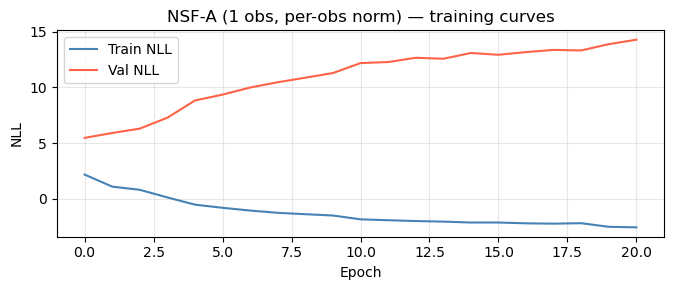

In [9]:
print('Precomputing contexts (CNN-A)...')
ctx_trA  = get_contexts(cnn_A, ds_A1)
ctx_valA = get_contexts(cnn_A, ds_val)
ctx_teA  = get_contexts(cnn_A, ds_test)
print(f'Context shape: {tuple(ctx_trA.shape)}')

flow_A, tr_nll_A, val_nll_A = train_nsf(
    ctx_trA, Y_A1_s, ctx_valA, Y_val_s, name='NSF-A'
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tr_nll_A,  label='Train NLL', color='steelblue')
ax.plot(val_nll_A, label='Val NLL',   color='tomato')
ax.set(xlabel='Epoch', ylabel='NLL', title='NSF-A (1 obs, per-obs norm) — training curves')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [10]:
samp_A, y_pred_A, y_true_test = evaluate_flow(flow_A, ctx_teA, Y_test_s, scaler_y, mu_test)

print('NSF-A (1 obs, per-obs norm) — test-set metrics')
print(f'  {"Target":<14}  R²      r')
metrics_A = {}
for i, name in enumerate(TARGET_NAMES):
    r2 = r2_score(y_true_test[:, i], y_pred_A[:, i])
    pr, _ = pearsonr(y_true_test[:, i], y_pred_A[:, i])
    metrics_A[name] = dict(R2=r2, r=pr)
    print(f'  {name:<14}  {r2:.3f}   {pr:.3f}')

NSF-A (1 obs, per-obs norm) — test-set metrics
  Target          R²      r
  AIA 193         0.085   0.438
  AIA 304         0.043   0.325
  Mag flux        0.001   0.057
  |Mag flux|      0.005   0.084


## Experiment B — 3 Observations

Training on 3 observations (2012-01-14, 2013-01-01, 2013-01-04) with per-observation
normalisation — a controlled step before scaling to all 20 available observations.
Same validation (2012-01-01) and test (2012-01-05) sets as Experiment A.

CNN-B: early stop ep 17


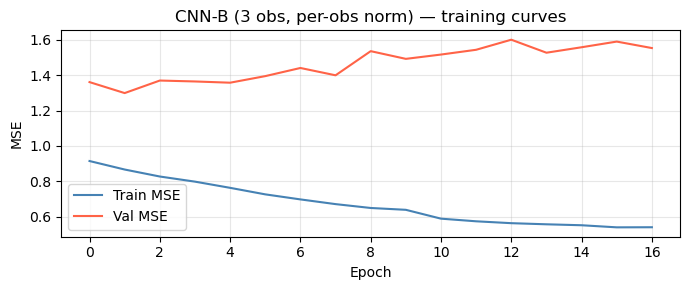

In [11]:
cnn_B = VanillaCNN().to(device)
tr_B, val_B = train_cnn(cnn_B, dl_trB, dl_val, name='CNN-B')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tr_B,  label='Train MSE', color='steelblue')
ax.plot(val_B, label='Val MSE',   color='tomato')
ax.set(xlabel='Epoch', ylabel='MSE', title='CNN-B (3 obs, per-obs norm) — training curves')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Precomputing contexts (CNN-B) for 3 training observations...


Training contexts: (95980, 128)


NSF-B: early stop ep 21
NSF-B: best val NLL = 2.8445


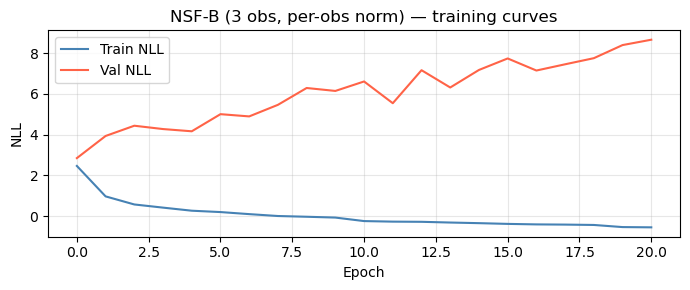

In [12]:
print(f'Precomputing contexts (CNN-B) for {len(ds_B_list)} training observations...')
ctx_trB_parts = [get_contexts(cnn_B, ds) for ds in ds_B_list]
ctx_trB = torch.cat(ctx_trB_parts, dim=0)
Y_trB   = torch.cat(Y_B_s_list,   dim=0)

ctx_valB = get_contexts(cnn_B, ds_val)
ctx_teB  = get_contexts(cnn_B, ds_test)
print(f'Training contexts: {tuple(ctx_trB.shape)}')

flow_B, tr_nll_B, val_nll_B = train_nsf(
    ctx_trB, Y_trB, ctx_valB, Y_val_s, name='NSF-B'
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tr_nll_B,  label='Train NLL', color='steelblue')
ax.plot(val_nll_B, label='Val NLL',   color='tomato')
ax.set(xlabel='Epoch', ylabel='NLL',
       title=f'NSF-B ({len(ds_B_list)} obs, per-obs norm) — training curves')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [13]:
samp_B, y_pred_B, _ = evaluate_flow(flow_B, ctx_teB, Y_test_s, scaler_y, mu_test)

print('NSF-B (3 obs, per-obs norm) — test-set metrics')
print(f'  {"Target":<14}  R²      r')
metrics_B = {}
for i, name in enumerate(TARGET_NAMES):
    r2 = r2_score(y_true_test[:, i], y_pred_B[:, i])
    pr, _ = pearsonr(y_true_test[:, i], y_pred_B[:, i])
    metrics_B[name] = dict(R2=r2, r=pr)
    print(f'  {name:<14}  {r2:.3f}   {pr:.3f}')

NSF-B (3 obs, per-obs norm) — test-set metrics
  Target          R²      r
  AIA 193         0.183   0.457
  AIA 304         0.063   0.305
  Mag flux        -0.001   0.003
  |Mag flux|      0.005   0.089


## Comparison: 1 Observation vs 3 Observations

All plots use the same held-out test set (2012-01-05).

  Target          R² (1 obs)  R² (3 obs)      Δ R²  r (1 obs)  r (3 obs)
  AIA 193              0.085       0.183    +0.099      0.438      0.457
  AIA 304              0.043       0.063    +0.020      0.325      0.305
  Mag flux             0.001      -0.001    -0.002      0.057      0.003
  |Mag flux|           0.005       0.005    +0.000      0.084      0.089


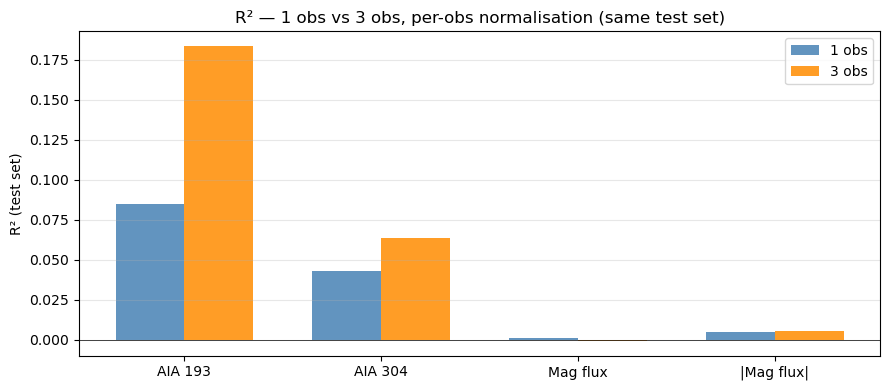

In [14]:
print(f'  {"Target":<14}  {"R² (1 obs)":>10}  {"R² (3 obs)":>10}  {"Δ R²":>8}  {"r (1 obs)":>9}  {"r (3 obs)":>9}')
for name in TARGET_NAMES:
    r2a = metrics_A[name]['R2']; r2b = metrics_B[name]['R2']
    ra  = metrics_A[name]['r'];  rb  = metrics_B[name]['r']
    print(f'  {name:<14}  {r2a:10.3f}  {r2b:10.3f}  {r2b-r2a:+8.3f}  {ra:9.3f}  {rb:9.3f}')

x = np.arange(len(TARGET_NAMES)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, [metrics_A[n]['R2'] for n in TARGET_NAMES], w,
       color='steelblue',  alpha=0.85, label='1 obs')
ax.bar(x + w/2, [metrics_B[n]['R2'] for n in TARGET_NAMES], w,
       color='darkorange', alpha=0.85, label='3 obs')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(TARGET_NAMES)
ax.set(ylabel='R² (test set)', title='R² — 1 obs vs 3 obs, per-obs normalisation (same test set)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

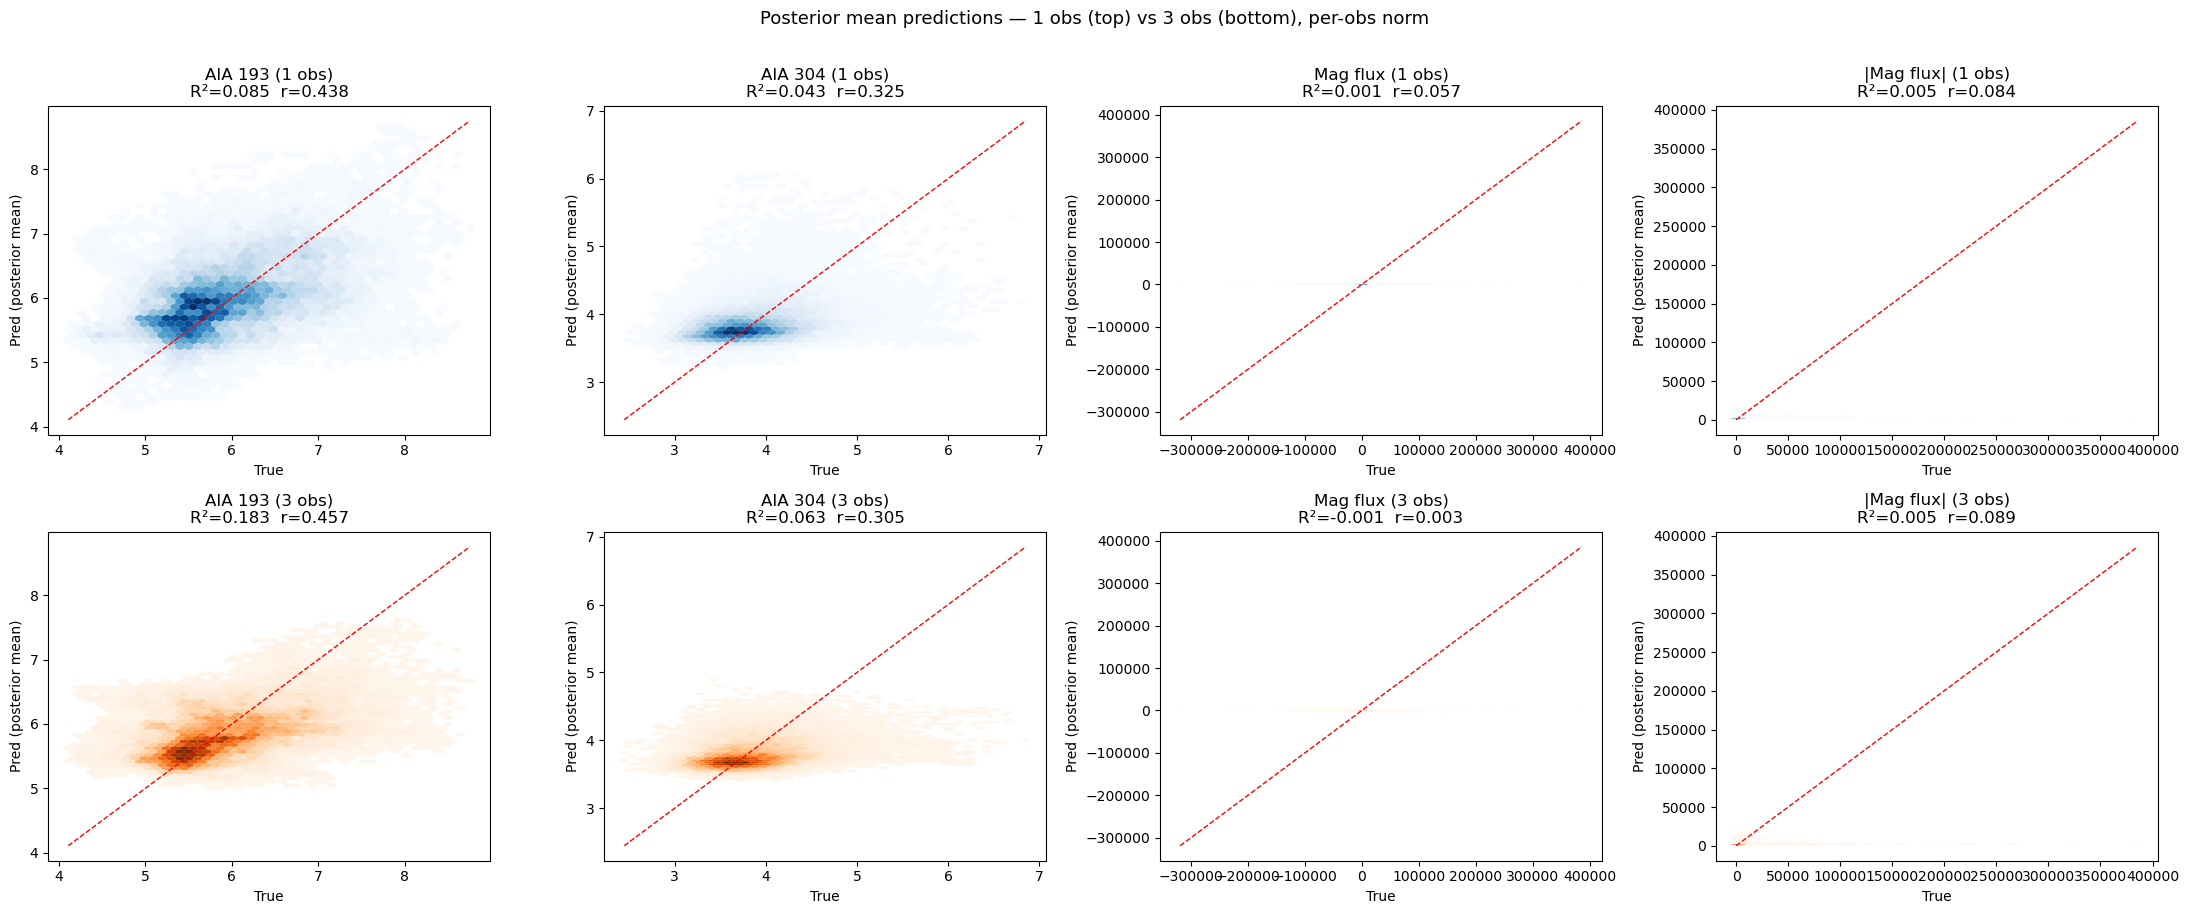

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for col, name in enumerate(TARGET_NAMES):
    for row_i, (y_pred, samp, label, cmap) in enumerate([
        (y_pred_A, samp_A, '1 obs',  'Blues'),
        (y_pred_B, samp_B, '3 obs',  'Oranges'),
    ]):
        ax = axes[row_i, col]
        yt, yp = y_true_test[:, col], y_pred[:, col]
        r2 = r2_score(yt, yp); pr, _ = pearsonr(yt, yp)
        ax.hexbin(yt, yp, gridsize=45, cmap=cmap, mincnt=1, linewidths=0.1)
        lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
        ax.set(title=f'{name} ({label})\nR²={r2:.3f}  r={pr:.3f}',
               xlabel='True', ylabel='Pred (posterior mean)')
plt.suptitle('Posterior mean predictions — 1 obs (top) vs 3 obs (bottom), per-obs norm',
             y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

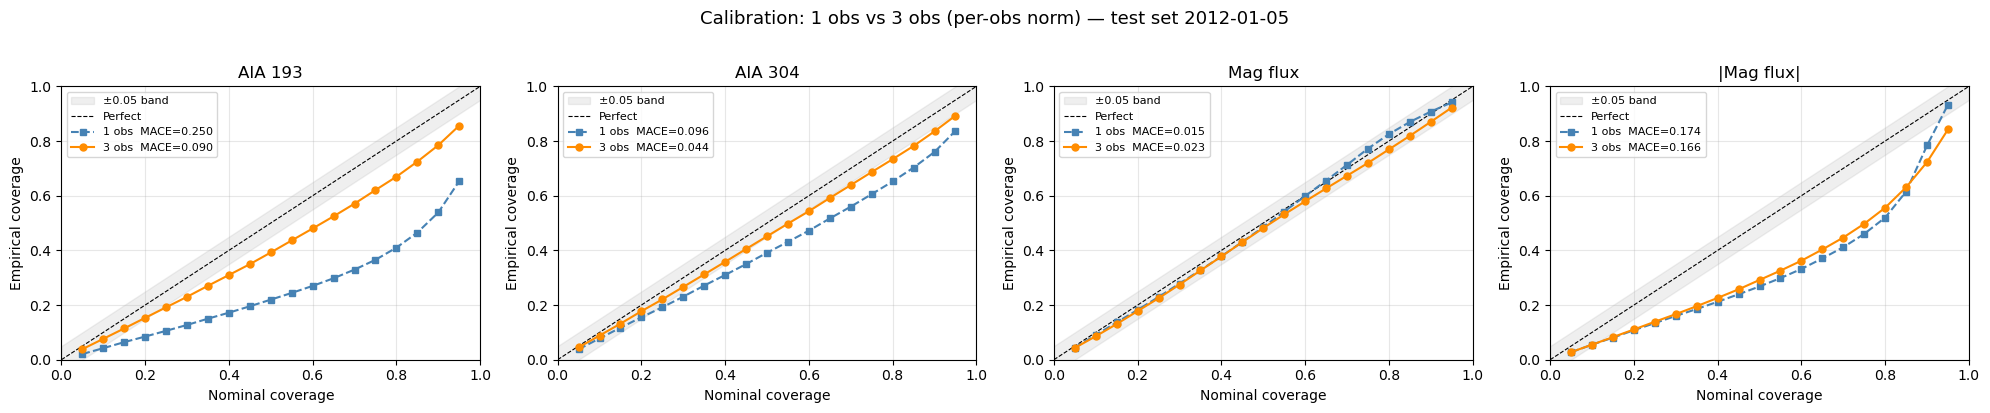

In [16]:
LEVELS = np.linspace(0.05, 0.95, 19)
y_te_s_np = Y_test_s.numpy()

cov_A = emp_coverage(samp_A, y_te_s_np, LEVELS)
cov_B = emp_coverage(samp_B, y_te_s_np, LEVELS)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (ax, name) in enumerate(zip(axes, TARGET_NAMES)):
    ax.fill_between([0,1],[-0.05,0.95],[0.05,1.05], color='grey', alpha=0.12, label='±0.05 band')
    ax.plot([0,1],[0,1],'k--', lw=0.8, label='Perfect')
    mA = np.mean(np.abs(cov_A[:,i] - LEVELS))
    mB = np.mean(np.abs(cov_B[:,i] - LEVELS))
    ax.plot(LEVELS, cov_A[:,i], 's--', color='steelblue',  ms=5, label=f'1 obs  MACE={mA:.3f}')
    ax.plot(LEVELS, cov_B[:,i], 'o-',  color='darkorange', ms=5, label=f'3 obs  MACE={mB:.3f}')
    ax.set(xlim=(0,1), ylim=(0,1), title=name,
           xlabel='Nominal coverage', ylabel='Empirical coverage')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Calibration: 1 obs vs 3 obs (per-obs norm) — test set 2012-01-05',
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

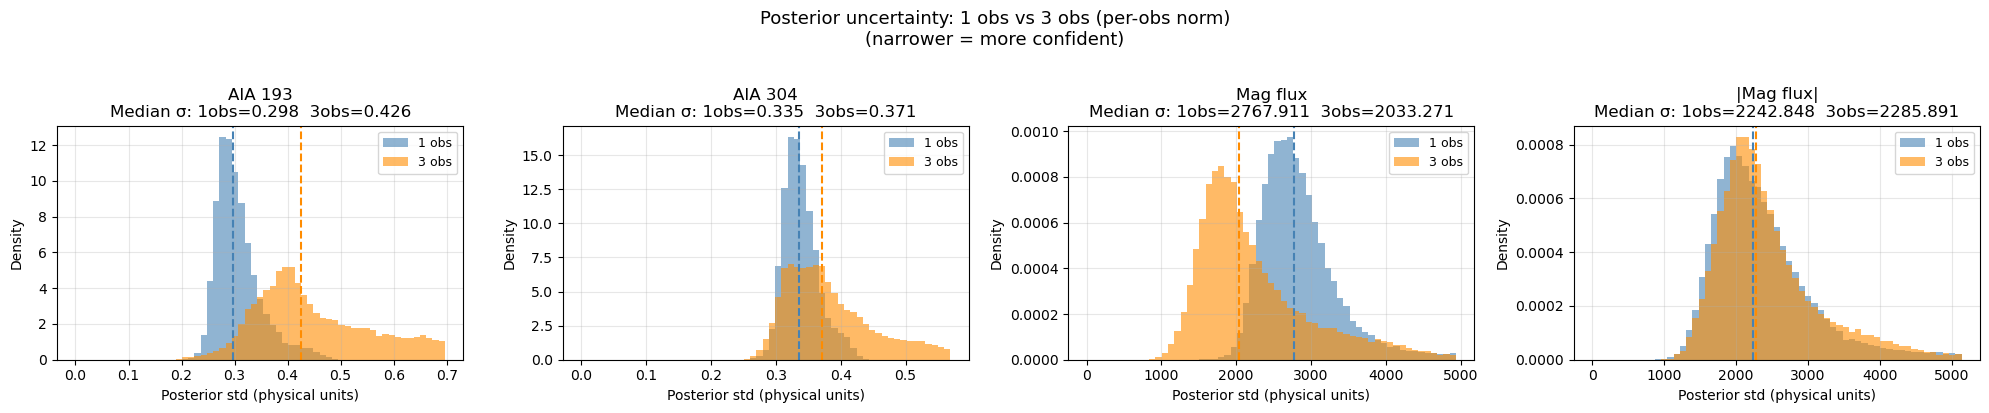

In [17]:
samp_A_phys = to_physical_samp(samp_A, scaler_y, mu_test)
samp_B_phys = to_physical_samp(samp_B, scaler_y, mu_test)

std_A = samp_A_phys.std(axis=1)   # (N_te, 4)
std_B = samp_B_phys.std(axis=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (ax, name) in enumerate(zip(axes, TARGET_NAMES)):
    bins = np.linspace(0, np.percentile(np.concatenate([std_A[:,i], std_B[:,i]]), 98), 60)
    ax.hist(std_A[:,i], bins=bins, color='steelblue',  alpha=0.6, label='1 obs', density=True)
    ax.hist(std_B[:,i], bins=bins, color='darkorange', alpha=0.6, label='3 obs', density=True)
    ax.axvline(np.median(std_A[:,i]), color='steelblue',  lw=1.5, ls='--')
    ax.axvline(np.median(std_B[:,i]), color='darkorange', lw=1.5, ls='--')
    ax.set(title=f'{name}\nMedian σ: 1obs={np.median(std_A[:,i]):.3f}  3obs={np.median(std_B[:,i]):.3f}',
           xlabel='Posterior std (physical units)', ylabel='Density')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Posterior uncertainty: 1 obs vs 3 obs (per-obs norm)\n(narrower = more confident)',
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()